# 🍿 Netflix Data Cleaning & Exploratory Data Analysis

## 📌 Objective
Clean, preprocess, and analyze Netflix Movies and TV Shows dataset using Python.

This project includes:
- Data cleaning
- Feature engineering
- Exploratory Data Analysis (EDA)
## 📦 Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [4]:
df = pd.read_csv('../data/netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Basic Exploration

In [6]:
df.shape
df.info()
df.isnull().sum().sort_values(ascending=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64

## 🧹 Data Cleaning

In [8]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Not Available')
df['country'] = df['country'].fillna(df['country'].mode()[0])
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

## 🎬 Duration Cleaning

In [10]:
df['duration'] = df['duration'].fillna('0 min')

df['duration_number'] = df['duration'].str.extract(r'(\\d+)')
df['duration_number'] = pd.to_numeric(df['duration_number'], errors='coerce').fillna(0)

df['duration_unit'] = df['duration'].str.extract(r'([A-Za-z]+)')
df['duration_unit'] = df['duration_unit'].fillna('Unknown')

## 🔁 Final Cleaning

In [12]:
df = df.drop_duplicates()
df.columns = df.columns.str.lower()

## 🧠 Feature Engineering

In [14]:
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

## ✅ Final Validation

In [16]:
print('Missing Values:\n', df.isnull().sum())
print('Duplicates:', df.duplicated().sum())
print('Shape:', df.shape)

Missing Values:
 show_id             0
type                0
title               0
director            0
cast                0
country             0
date_added         98
release_year        0
rating              0
duration            0
listed_in           0
description         0
duration_number     0
duration_unit       0
year_added         98
month_added        98
dtype: int64
Duplicates: 0
Shape: (8807, 16)


## 📊 Exploratory Data Analysis (EDA)

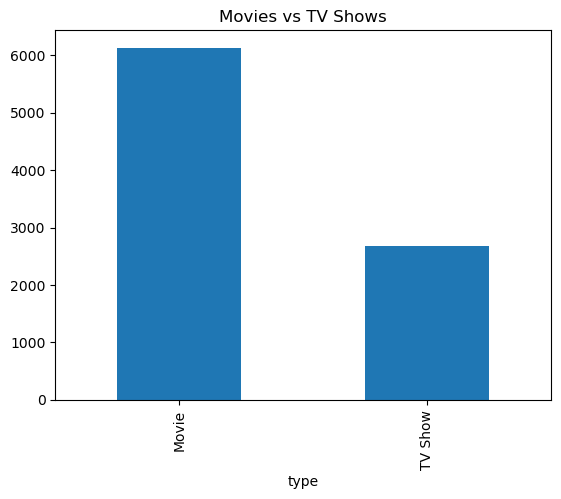

In [18]:
df['type'].value_counts().plot(kind='bar')
plt.title('Movies vs TV Shows')
plt.show()

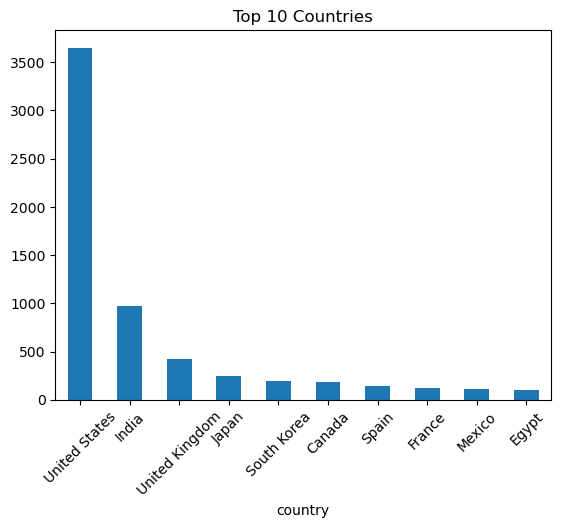

In [19]:
df['country'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Countries')
plt.xticks(rotation=45)
plt.show()

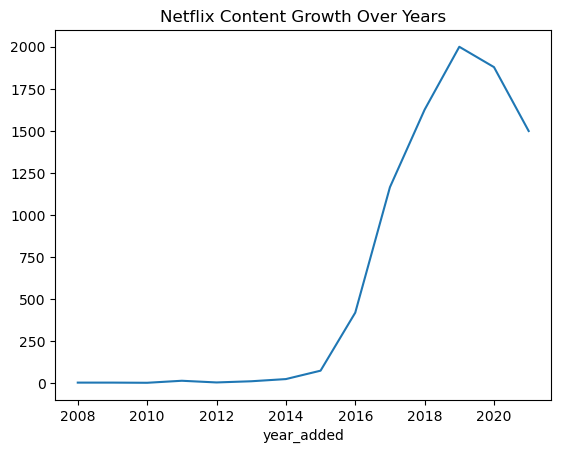

In [20]:
df['year_added'].value_counts().sort_index().plot(kind='line')
plt.title('Netflix Content Growth Over Years')
plt.show()

## 💾 Save Clean Dataset

In [22]:
df.to_csv('../data/netflix_cleaned.csv', index=False)
print('Clean dataset saved successfully!')

Clean dataset saved successfully!
